In [51]:
import sys
sys.path.append('..')  # 让 Python 能找到上一级目录（即 energy_reconstruction）

# 历史分析 notebook：当前维护的主线代码在 src/theta 和 src/common
from src.common import utils
from src.common.EdgeConv import EdgeConvBlock
from src.theta.ParticleDataset_theta import ParticleDataset
from src.theta.ParticleRegressor_theta import ParticleNetRegressor
from src.theta.train_theta import train_model
from src.theta.evaluate_theta import evaluate_model


In [52]:
# === WCDA footprint demo ===
from pathlib import Path
import random
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.font_manager import FontProperties

try:
    import uproot
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('当前环境缺少 `uproot`，请先安装后再运行这个 ROOT 读取示例。') from exc

project_root_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path('/mnt/mydisk/server/projects/energy_reconstruction'),
    Path('/home/server/projects/energy_reconstruction'),
]
for candidate in project_root_candidates:
    wcda_config_path = candidate / 'src' / 'common' / 'WCDA_configuration.py'
    survey_path = candidate / 'src' / 'common' / 'wcda_surveyx.txt'
    if wcda_config_path.exists() and survey_path.exists():
        common_dir = candidate / 'src' / 'common'
        break
else:
    raise FileNotFoundError('找不到 src/common/WCDA_configuration.py 或 src/common/wcda_surveyx.txt')

if str(common_dir) not in sys.path:
    sys.path.insert(0, str(common_dir))

from WCDA_configuration import WCDAConfig

root_dir_candidates = [
    Path('/mnt/mydisk/WCDA_simulation'),
    Path('/home/server/mydisk/WCDA_simulation'),
]
for root_dir in root_dir_candidates:
    root_files = sorted(root_dir.glob('*.root'))
    if root_files:
        break
else:
    raise FileNotFoundError('找不到 WCDA_simulation 目录下的 ROOT 文件。')

candidate_font_paths = [
    Path('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'),
    Path('/usr/share/fonts/truetype/arphic/uming.ttc'),
]
cjk_font = None
for font_path in candidate_font_paths:
    if font_path.exists():
        cjk_font = FontProperties(fname=str(font_path))
        break

plt.rcParams['axes.unicode_minus'] = False

cfg = WCDAConfig(str(survey_path))
selected_root = random.Random(42).choice(root_files)

required_branches = [
    'vx', 'vy',
    'vidmc', 'vq', 'vflag',
    'xc', 'yc', 'mc_xc', 'mc_yc',
    'mc_energy', 'mc_theta', 'mc_phi', 'mc_dcore',
]

with uproot.open(selected_root) as root_file:
    if 't_eventout;1' not in root_file:
        raise KeyError(f'{selected_root} 中没有 t_eventout;1')

    tree = root_file['t_eventout;1']
    missing = [branch for branch in required_branches if branch not in tree.keys()]
    if missing:
        raise KeyError(f'{selected_root} 缺少分支: {missing}')

    branches_to_load = list(required_branches)
    event_idx_from_root = 'event_idx' in tree.keys()
    if event_idx_from_root:
        branches_to_load.append('event_idx')

    df_root = tree.arrays(branches_to_load, library='pd')
    if not event_idx_from_root:
        df_root['event_idx'] = np.arange(tree.num_entries, dtype=int)

df_root['file'] = str(selected_root)
print(f'Loaded {len(df_root)} events from {selected_root}')
print(f'Loaded WCDA config from {survey_path}')
print('event_idx source:', 'ROOT branch' if event_idx_from_root else 'generated from tree entry index')
if cjk_font is not None:
    print(f'Using CJK font: {cjk_font.get_file()}')


/mnt/mydisk/server/projects/energy_reconstruction/src/common/WCDA_configuration.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  self.df = pd.read_csv(filename, delim_whitespace=True, comment="#")


Loaded 3914 events from /mnt/mydisk/WCDA_simulation/Egr000001824_01_n0010_eventout.root
Loaded WCDA config from /mnt/mydisk/server/projects/energy_reconstruction/src/common/wcda_surveyx.txt
event_idx source: generated from tree entry index
Using CJK font: /usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc


In [53]:
# === WCDA footprint demo ===
def _draw_event_footprint_axis(ax, x_values, y_values, charges, vflag, row, df, use_pools=True, xlim=(-300, 300), ylim=(-260, 260), title=''):
    code = (vflag // 10000) % 10
    mask_real = (vflag > 0) & np.isin(code, [1, 3])
    mask_noise = (vflag > 0) & np.isin(code, [2, 4])

    if use_pools:
        pool1 = [(-150, -130), (-150, 20), (0, 20), (0, -130)]
        pool2 = [(0, -130), (0, 20), (150, 20), (150, -130)]
        pool3 = [(-150, 20), (-150, 130), (150, 130), (150, 20)]
        for pool in (pool1, pool2, pool3):
            ax.add_patch(Polygon(pool, closed=True, edgecolor='black', facecolor='none', linewidth=1))

    s_real = 5.0 * np.log10(charges[mask_real] + 1.0)
    s_noise = 5.0 * np.log10(charges[mask_noise] + 1.0)

    ax.scatter(x_values[mask_real], y_values[mask_real], s=s_real, c='blue', label='real')
    ax.scatter(x_values[mask_noise], y_values[mask_noise], s=s_noise, c='red', label='noise')

    if 'xc' in df.columns and 'yc' in df.columns:
        ax.scatter(row['xc'], row['yc'], c='purple', label='rec core')
    if 'mc_xc' in df.columns and 'mc_yc' in df.columns:
        ax.scatter(row['mc_xc'], row['mc_yc'], c='green', label='true core')

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')


def plot_event_footprint(df, i, use_pools=True, xlim=(-300, 300), ylim=(-260, 260)):
    """
    左图: 参考 11.ipynb 的 local footprint (vx, vy)
    右图: 使用 cfg.get_xy(vidmc) 的 global footprint
    """

    row = df.iloc[i]

    x_local = np.asarray(row['vx'])
    y_local = np.asarray(row['vy'])
    charges = np.asarray(row['vq'])
    vflag = np.asarray(row['vflag'])
    detector_ids = np.asarray(row['vidmc'], dtype=int)

    if not (len(x_local) == len(y_local) == len(charges) == len(vflag) == len(detector_ids)):
        raise ValueError('vx, vy, vidmc, vq, vflag 的长度不一致，无法绘制 footprint。')

    x_det_values = []
    y_det_values = []
    vcol_values = []
    vrow_values = []
    for detector_id in detector_ids:
        x_det_single, y_det_single = cfg.get_xy(int(detector_id))
        vcol_single, vrow_single = cfg.get_col_row(int(detector_id))
        x_det_values.append(float(np.asarray(x_det_single).reshape(-1)[0]))
        y_det_values.append(float(np.asarray(y_det_single).reshape(-1)[0]))
        vcol_values.append(int(np.asarray(vcol_single).reshape(-1)[0]))
        vrow_values.append(int(np.asarray(vrow_single).reshape(-1)[0]))

    x_det = np.asarray(x_det_values, dtype=float)
    y_det = np.asarray(y_det_values, dtype=float)
    vcol = np.asarray(vcol_values, dtype=int)
    vrow = np.asarray(vrow_values, dtype=int)
    _ = (vcol, vrow)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    _draw_event_footprint_axis(
        axes[0],
        x_values=x_local,
        y_values=y_local,
        charges=charges,
        vflag=vflag,
        row=row,
        df=df,
        use_pools=use_pools,
        xlim=xlim,
        ylim=ylim,
        title='local (vx, vy)',
    )
    _draw_event_footprint_axis(
        axes[1],
        x_values=x_det,
        y_values=y_det,
        charges=charges,
        vflag=vflag,
        row=row,
        df=df,
        use_pools=use_pools,
        xlim=xlim,
        ylim=ylim,
        title='global (get_xy from vidmc)',
    )

    handles, labels = axes[0].get_legend_handles_labels()
    axes[1].legend(handles, labels, loc='upper right')

    info = (
        f'energy: {row["mc_energy"] / 1e3:.2f} TeV\n'
        f'theta: {np.degrees(row["mc_theta"]):.2f}°\n'
        f'phi: {np.degrees(row["mc_phi"]):.2f}°\n'
        f'dcore: {row["mc_dcore"]:.2f} m\n'
        f'abs_err: {row.get("abs_err", np.nan):.4g}'
    )
    fig.text(0.92, 0.5, info, va='center', fontsize=10)
    fig.suptitle(f'event_idx={row.get("event_idx", "NA")}  file={row.get("file", "NA")}')
    fig.tight_layout(rect=(0, 0, 0.9, 0.95))
    plt.show()


In [54]:
# === WCDA footprint demo ===
plot_count = min(5, len(df_root))
selected_events = df_root.sample(plot_count, random_state=42).reset_index(drop=True)
print('随机选中的 ROOT 文件：')
print(selected_root)
print()
print('随机选中的 event：')
cols = [col for col in ['event_idx', 'mc_energy', 'mc_dcore'] if col in selected_events.columns]
print(selected_events[cols].to_string(index=False))


随机选中的 ROOT 文件：
/mnt/mydisk/WCDA_simulation/Egr000001824_01_n0010_eventout.root

随机选中的 event：
 event_idx    mc_energy   mc_dcore
      1964    17.463873 191.854566
      2742 54077.179688  13.068097
       366    67.794876  92.590833
      3089   185.886856 350.582323
      1422    50.318142  75.502721


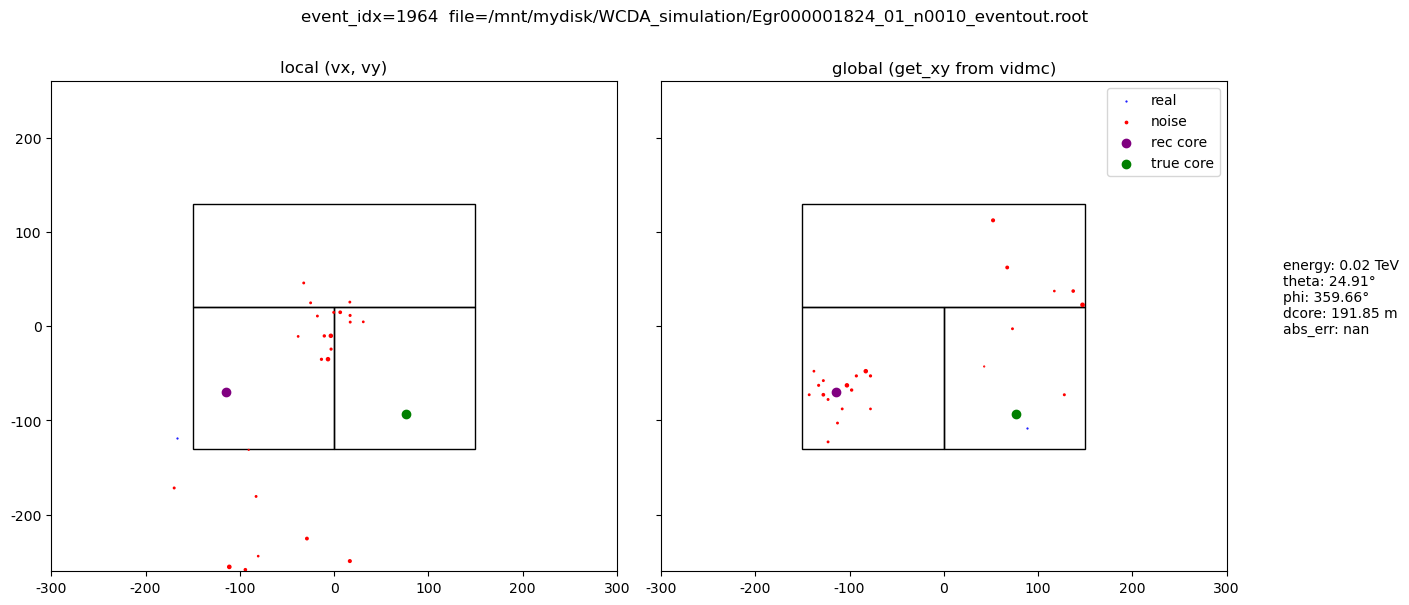

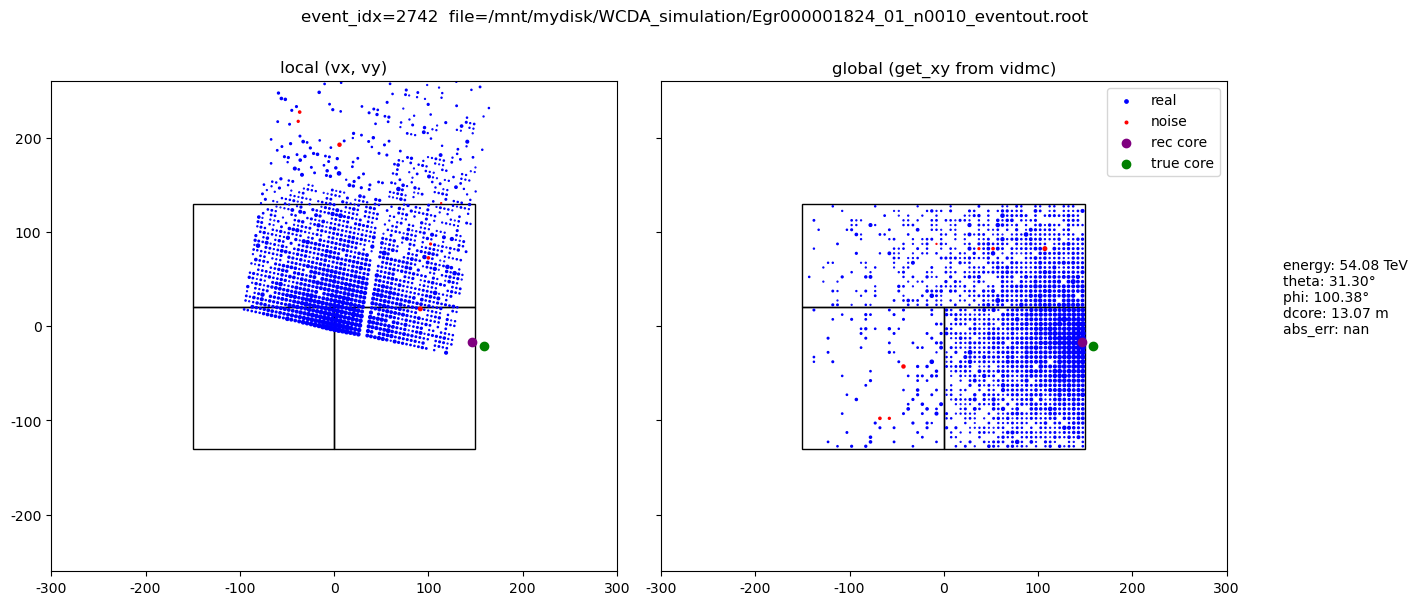

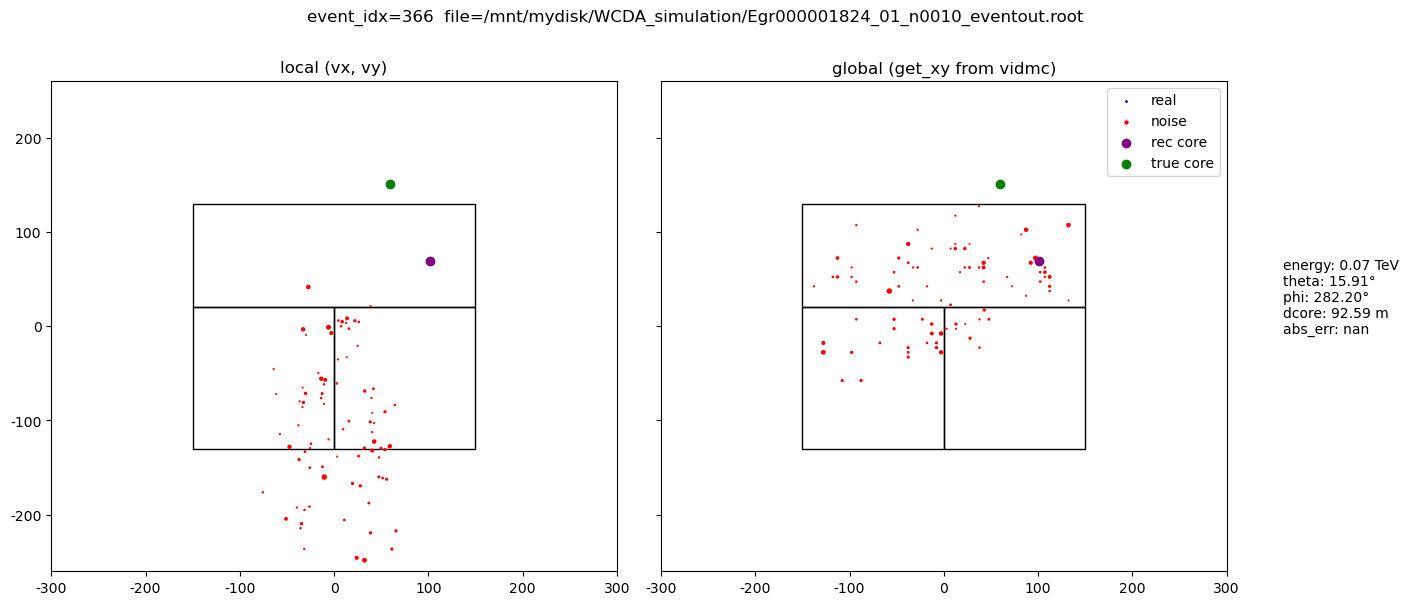

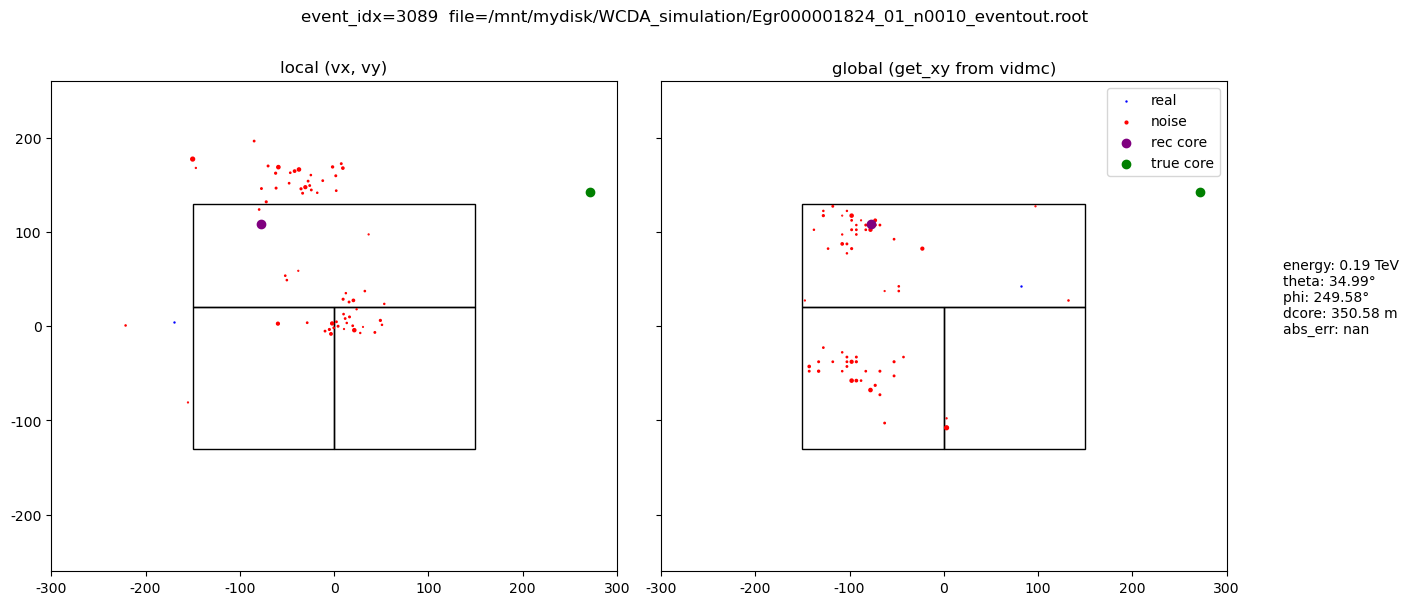

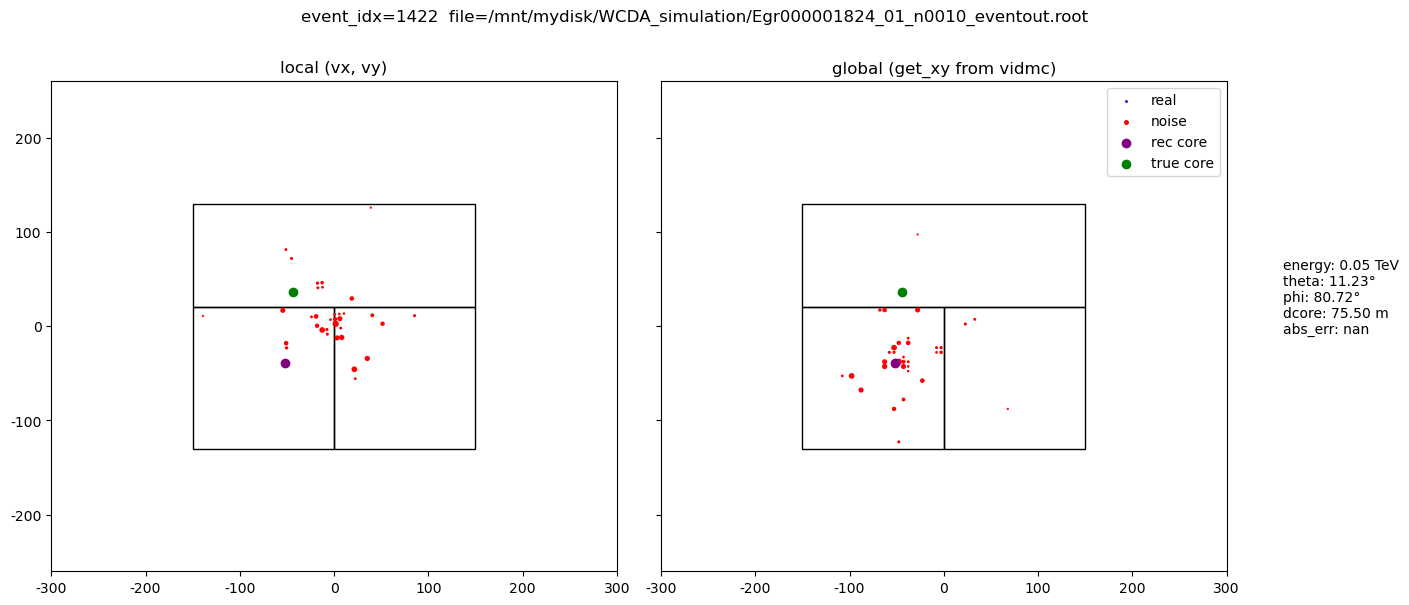

In [55]:
# === WCDA footprint demo ===
for i in range(len(selected_events)):
    plot_event_footprint(selected_events, i)
